# 12장 실습 ③ — 모델이 어디를 보는가

**PyTorch 판**

어텐션의 큰 장점 하나는 **가중치를 꺼내 볼 수 있다**는 것입니다.
9장의 Grad-CAM이 영상에서 한 일을, 어텐션은 **구조 자체로** 합니다.

## 12.0 준비

In [1]:
try:
    import dlbook
except ImportError:
    !pip install -q "dlbook @ git+https://github.com/dhrim/deep-learning-in-one-semester.git"
    import dlbook

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import dlbook
from dlbook import data, metrics, plot

dlbook.set_seed(42)
plot.use_korean()
print(dlbook.versions())

{'python': '3.12.3', 'numpy': '2.1.3', 'keras': '-', 'tensorflow': '-', 'torch': '2.14.0', 'keras_backend': '-'}


## 12.1 실험대 — 11장의 어려운 규칙

**Conv1D가 0.949에 머물고 LSTM만 1.000을 냈던** 그 과제입니다.
어텐션이 어떻게 하는지 봅니다.

In [3]:
# 11장 §11.9의 「어려운 규칙」을 그대로 씁니다.
# 감성 단어가 둘(부호 반대), 정답은 **먼저 나온 쪽**을 따릅니다.
V = len(data.TOY_VOCAB)
LENGTH = 16
x, y = data.toy_reviews(n=8000, length=LENGTH, seed=42, hard=True)
sp = data.split(x, y, val_ratio=0.2, test_ratio=0.2, seed=42)
print(sp.summary())
print()
for k in range(3):
    print(f"  {data.toy_decode(x[k]):<52} → {'긍정' if y[k] else '부정'}")
print()
print("이 과제는 **떨어져 있는 두 자리를 견주어야** 풀립니다.")
print("11장에서 Conv1D가 0.949에 머물고 LSTM만 1.000을 냈던 그 과제입니다.")

구분            개수  입력 shape
train       4800  (16,)
val         1600  (16,)
test        1600  (16,)

  배우 어제 이야기 안 실망이다 그냥 안 재미있다 친구랑 친구랑                   → 긍정
  그냥 음악 안 좋다 역시 안 아쉽다 매우 정말                            → 부정
  조금 안 재미있다 영화 다시 다시 지루하다                              → 부정

이 과제는 **떨어져 있는 두 자리를 견주어야** 풀립니다.
11장에서 Conv1D가 0.949에 머물고 LSTM만 1.000을 냈던 그 과제입니다.


## 12.2 위치 인코딩

어텐션에는 **순서 개념이 없습니다.** 그래서 순서를 **입력에 심어** 줍니다.

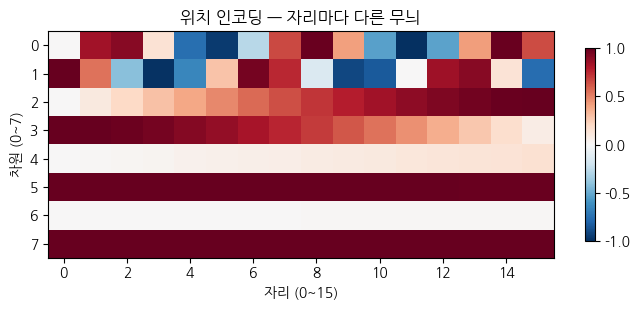

→ 세로줄 하나가 자리 하나입니다. **자리마다 무늬가 다릅니다.**
→ 이것을 임베딩에 더하면 같은 단어라도 자리가 다르면 다른 벡터가 됩니다.


In [4]:
# 위치 인코딩 — 사인·코사인. (Vaswani et al. 2017)
# 순수 numpy입니다. 세 판이 **완전히 같습니다.**
def positional_encoding(length, depth):
    """자리마다 다른 값을 갖는 (length, depth) 행렬을 만든다.

    같은 자리는 늘 같은 값이고, 가까운 자리끼리는 비슷한 값이 된다.
    이것을 임베딩에 **더해** 주면 "몇 번째 단어인가"가 표현에 들어간다.
    """
    pos = np.arange(length)[:, None]
    i = np.arange(depth)[None, :]
    angle = pos / np.power(10000.0, (2 * (i // 2)) / depth)
    pe = np.zeros((length, depth), dtype="float32")
    pe[:, 0::2] = np.sin(angle[:, 0::2])
    pe[:, 1::2] = np.cos(angle[:, 1::2])
    return pe

PE = positional_encoding(LENGTH, 8)

fig, ax = plt.subplots(figsize=(7.0, 3.2))
im = ax.imshow(PE.T, aspect="auto", cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xlabel("자리 (0~15)"); ax.set_ylabel("차원 (0~7)")
ax.set_title("위치 인코딩 — 자리마다 다른 무늬")
fig.colorbar(im, ax=ax, shrink=0.85); plt.tight_layout(); plt.show()

print("→ 세로줄 하나가 자리 하나입니다. **자리마다 무늬가 다릅니다.**")
print("→ 이것을 임베딩에 더하면 같은 단어라도 자리가 다르면 다른 벡터가 됩니다.")

## 12.3 모델 정의 — 여기만 판마다 다릅니다

**PyTorch 판의 `batch_first=True`** 에 주목하십시오. 이것을 빼면
`nn.MultiheadAttention` 은 (길이, 배치, 차원) 순서를 기대합니다.
**오류 없이 조용히 틀린 결과가 나오는** 자리입니다.

In [5]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

device = "cuda" if torch.cuda.is_available() else "cpu"

class TextModel(nn.Module):
    """임베딩 위에 무엇을 올리느냐만 다릅니다.

    PyTorch의 nn.MultiheadAttention 은 batch_first=True 를 주지 않으면
    (길이, 배치, 차원) 순서를 기대합니다. **자주 틀리는 자리입니다.**
    """
    def __init__(self, kind, V, L, d=8):
        super().__init__()
        self.kind, self.L, self.d = kind, L, d
        self.emb = nn.Embedding(V, d)
        if kind in ("attn", "attn_pos"):
            self.att = nn.MultiheadAttention(d, num_heads=2, batch_first=True)
            self.norm = nn.LayerNorm(d)
            n_out = d
        elif kind == "cnn":
            self.conv = nn.Conv1d(d, 16, 3); n_out = 16
        elif kind == "lstm":
            self.rnn = nn.LSTM(d, 32, batch_first=True); n_out = 32
        if kind == "attn_pos":
            self.register_buffer(
                "pe", torch.tensor(positional_encoding(L, d)))
        self.head = nn.Linear(n_out, 1)

    def forward(self, x, return_weights=False):
        e = self.emb(x.long())
        if self.kind == "attn_pos":
            e = e + self.pe
        if self.kind in ("attn", "attn_pos"):
            a, w = self.att(e, e, e, need_weights=True, average_attn_weights=False)
            h = self.norm(e + a).mean(1)
            if return_weights:
                return w
        elif self.kind == "cnn":
            h = torch.relu(self.conv(e.transpose(1, 2))).max(dim=2).values
        else:
            out, _ = self.rnn(e); h = out[:, -1]
        return self.head(h)

_FIT = {}

def train_text(kind, sp, lr=0.003, seed=42, epochs=25):
    """(시험 정확도, 파라미터 수, 모델) 을 돌려준다."""
    dlbook.set_seed(seed)
    V, L = len(data.TOY_VOCAB), sp.x_train.shape[1]
    model = TextModel(kind, V, L).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.BCEWithLogitsLoss()
    dl = DataLoader(TensorDataset(
        torch.tensor(sp.x_train, dtype=torch.long),
        torch.tensor(sp.y_train, dtype=torch.float32).view(-1, 1)),
        batch_size=64, shuffle=True)
    for _ in range(dlbook.smoke.epochs(epochs)):
        model.train()
        for xx, yy in dl:
            xx, yy = xx.to(device), yy.to(device)
            opt.zero_grad(); loss_fn(model(xx), yy).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
    _FIT[kind] = model
    n_params = sum(p.numel() for p in model.parameters())
    return predict_acc(kind, sp, sp.x_test), n_params, model

def predict_acc(kind, sp, xs):
    model = _FIT[kind]; model.eval()
    with torch.no_grad():
        out = model(torch.tensor(xs, dtype=torch.long).to(device))
    return metrics.accuracy(sp.y_test, (out.cpu().numpy().reshape(-1) > 0).astype(int))

def attention_weights(model, xs):
    """학습된 모델에서 어텐션 가중치를 꺼낸다. (머리, 질의, 키)"""
    model.eval()
    with torch.no_grad():
        w = model(torch.tensor(xs, dtype=torch.long).to(device),
                  return_weights=True)
    return w.cpu().numpy()[0]

## 12.1 어텐션 가중치 꺼내 보기

시험 정확도 0.756
문장: 음악 그냥 안 아쉽다 정말 정말 어제 감동적이다
정답: 긍정


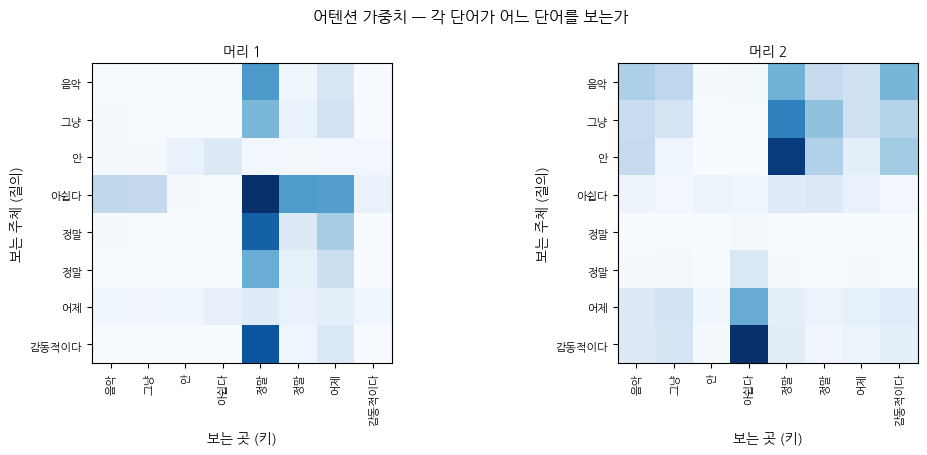


→ 한 줄이 단어 하나입니다. 그 줄에서 **진한 칸이 그 단어가 보는 곳**입니다.
→ 감성 단어와 '안'이 있는 열이 진해지는지 보십시오.
→ 머리가 둘이면 **서로 다른 것을 볼 수** 있습니다. 그것이 멀티헤드입니다.


In [6]:
# 어텐션 가중치를 꺼내 봅니다. **모델이 어디를 봤는지** 보입니다.
acc, _, model = train_text("attn_pos", sp)
W = attention_weights(model, sp.x_test[:1])       # (머리, 질의, 키)
print(f"시험 정확도 {acc:.3f}")

toks = [data.TOY_VOCAB[i] for i in sp.x_test[0] if i != 0]
n = len(toks)
print("문장:", " ".join(toks))
print("정답:", "긍정" if sp.y_test[0] else "부정")

fig, axes = plt.subplots(1, W.shape[0], figsize=(5.4 * W.shape[0], 4.6))
axes = np.atleast_1d(axes)
for h, ax in enumerate(axes):
    im = ax.imshow(W[h, :n, :n], cmap="Blues", vmin=0)
    ax.set_xticks(range(n)); ax.set_xticklabels(toks, rotation=90, fontsize=8)
    ax.set_yticks(range(n)); ax.set_yticklabels(toks, fontsize=8)
    ax.set_title(f"머리 {h + 1}", fontsize=10)
    ax.set_xlabel("보는 곳 (키)"); ax.set_ylabel("보는 주체 (질의)")
fig.suptitle("어텐션 가중치 — 각 단어가 어느 단어를 보는가", fontsize=11.5)
plt.tight_layout(); plt.show()

print()
print("→ 한 줄이 단어 하나입니다. 그 줄에서 **진한 칸이 그 단어가 보는 곳**입니다.")
print("→ 감성 단어와 '안'이 있는 열이 진해지는지 보십시오.")
print("→ 머리가 둘이면 **서로 다른 것을 볼 수** 있습니다. 그것이 멀티헤드입니다.")

## 정리

- 어텐션 가중치는 **모델이 어디를 봤는지**를 그대로 보여 줍니다.
  9장의 Grad-CAM처럼 따로 계산할 필요가 없습니다. **구조 안에 있습니다.**
- 다만 **가중치가 곧 설명은 아닙니다.** 어디를 봤는지는 알려 주지만
  왜 그렇게 판단했는지는 알려 주지 않습니다. 이 구분은 중요합니다.

### 연습

1. 여러 문장에 대해 그려 보고 **공통된 무늬**가 있는지 보십시오.
2. 위치 인코딩를 뺀 모델의 가중치를 그리십시오. 무엇이 달라집니까.
3. 머리 2개가 **서로 다른 것을 보는지** 확인하십시오.
4. (논술) 어텐션 가중치를 「설명」이라고 부르는 것이 정당한지 논하시오.